# Gradient Boosting Classifier

## Project

Pima Indians Diabetes Dataset Classification Models

---

## Objective

To implement the Gradient Boosting Classifier and evaluate its performance on the Pima Indians Diabetes Dataset. The goal is to compare its predictive ability with previously implemented classification and ensemble learning models.

---

## About Gradient Boosting

Gradient Boosting is an ensemble learning algorithm that combines multiple weak learners, usually shallow decision trees, to create a stronger predictive model.

Unlike AdaBoost, which focuses on increasing the importance of misclassified observations, Gradient Boosting focuses on reducing the residual errors (remaining mistakes) made by previous models.

Each new decision tree learns from these residual errors and attempts to minimise them, gradually improving the overall performance of the model.

---

## Why Gradient Boosting?

Gradient Boosting is widely used because it:

- Learns from the magnitude of prediction errors.
- Produces highly accurate predictive models.
- Handles complex, non-linear relationships effectively.
- Often outperforms many traditional machine learning algorithms when properly tuned.

---

## Workflow

1. Import the Gradient Boosting Classifier.
2. Create the model.
3. Train the model using the training dataset.
4. Generate predictions.
5. Evaluate performance using:
   - Accuracy
   - Classification Report
   - Confusion Matrix
   - ROC-AUC Score
6. Compare the results with previous ensemble learning models.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# LOAD DATASET

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# FEATURES AND TARGET

In [3]:
# Featues
X = df.drop("Outcome", axis=1)
# Target
y = df["Outcome"]

# TRAIN TEST SPLIT

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# TRAINING THE GRADIENTBOOST MODEL

In [6]:
# Creating the Gradient booat model
gb = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (imp

# MAKE PREDICIION

In [8]:
# Y_pred gives the final prediction of each patient
y_pred = gb.predict(X_test)
# Y_prob gives the probability of a patient being in class 1(Diabetic)
y_prob = gb.predict_proba(X_test)[:, 1]

# EVALUATING THE MODELS PERFORMANCE

In [9]:
# Accuracy
gb_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {gb_accuracy:.2f}")

Accuracy: 0.77


In [10]:
# Classification Report
cr = classification_report(y_test, y_pred)
print(f"Classification Report: {cr}")

Classification Report:               precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



Ada Confusion Matrix: [[79 20]
 [16 39]]


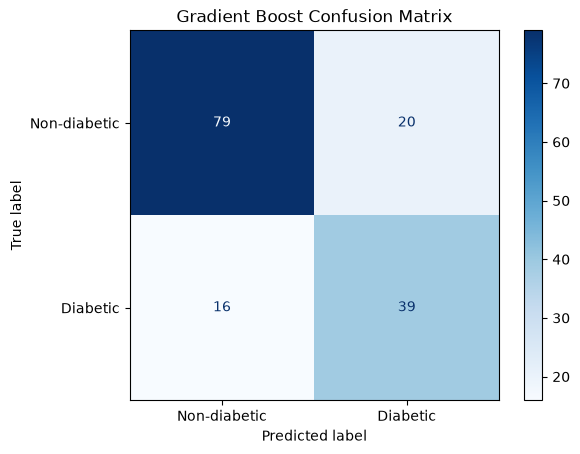

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Ada Confusion Matrix: {cm}")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)
disp.plot(cmap="Blues")
plt.title("Gradient Boost Confusion Matrix")
plt.show()

ROC-AUC Score: 0.82


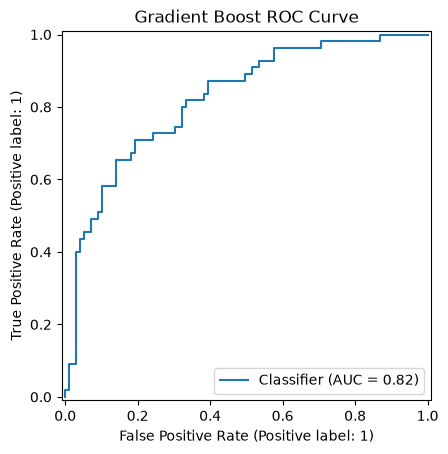

In [12]:
# ROC_AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(roc_auc, 2))
# ROC_AUC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Gradient Boost ROC Curve")
plt.show()

## COMPARISON OD ENSEMBLE LEARINGN MODELS SO FAR

The project implemented four ensemble learning models so far:

- Hard Voting Classifier
- Soft Voting Classifier
- AdaBoost Classifier
- Gradient Boosting Classifier

The table below summarizes their performance.

| Model | Accuracy | ROC-AUC | Recall (Diabetic) | Key Strength |
|--------|---------:|---------:|------------------:|--------------|
| Hard Voting | **0.77** | Not Applicable | **0.67** | Simple majority voting improves stability. |
| Soft Voting | **0.77** | **0.81** | **0.64** | Uses average prediction probabilities, providing better confidence estimates than Hard Voting. |
| AdaBoost | **0.77** | **0.81** | **0.73** | Highest recall among the ensemble models, identifying more diabetic patients correctly. |
| Gradient Boosting | **0.77** | **0.82** | **0.71** | Highest ROC-AUC, demonstrating the strongest overall class discrimination. |

### Interpretation

Although all four ensemble methods achieved the same overall accuracy (**77%**), they demonstrated different strengths.

- **Hard Voting** improved prediction stability by combining the final class predictions from multiple models. It is simple to implement but does not consider each model's confidence.
- **Soft Voting** improved upon Hard Voting by averaging the predicted probabilities of each model before making the final decision. This generally provides more reliable predictions and produced a strong ROC-AUC score of **0.81**.
- **AdaBoost** sequentially corrected the mistakes made by previous decision trees by assigning greater importance to misclassified observations. It achieved the highest recall (**0.73**) for diabetic patients, making it the most effective ensemble model for identifying positive diabetes cases.
- **Gradient Boosting** also learned sequentially but focused on reducing the residual errors made by previous models rather than adjusting sample weights. It produced the highest ROC-AUC score (**0.82**), indicating the strongest overall ability to distinguish between diabetic and non-diabetic patients across different classification thresholds.



# CONCLUSION

The ensemble learning models performed similarly in terms of overall accuracy, demonstrating that combining multiple learners generally leads to stable predictive performance.

However, each model excelled in different areas:

- **Hard Voting** provided a straightforward and robust ensemble approach.
- **Soft Voting** improved prediction confidence by utilising class probabilities.
- **AdaBoost** prioritised detecting diabetic patients and achieved the highest recall.
- **Gradient Boosting** achieved the strongest overall discrimination capability, reflected by the highest ROC-AUC score.

This comparison highlights that model selection should not rely solely on accuracy. Depending on the application, different evaluation metrics may be prioritised. In medical diagnosis, recall is particularly important to minimise missed disease cases, while ROC-AUC provides a broader measure of overall classification performance.